<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB
None
survived         0
pclass           0
sex              0
age            177
sibsp       

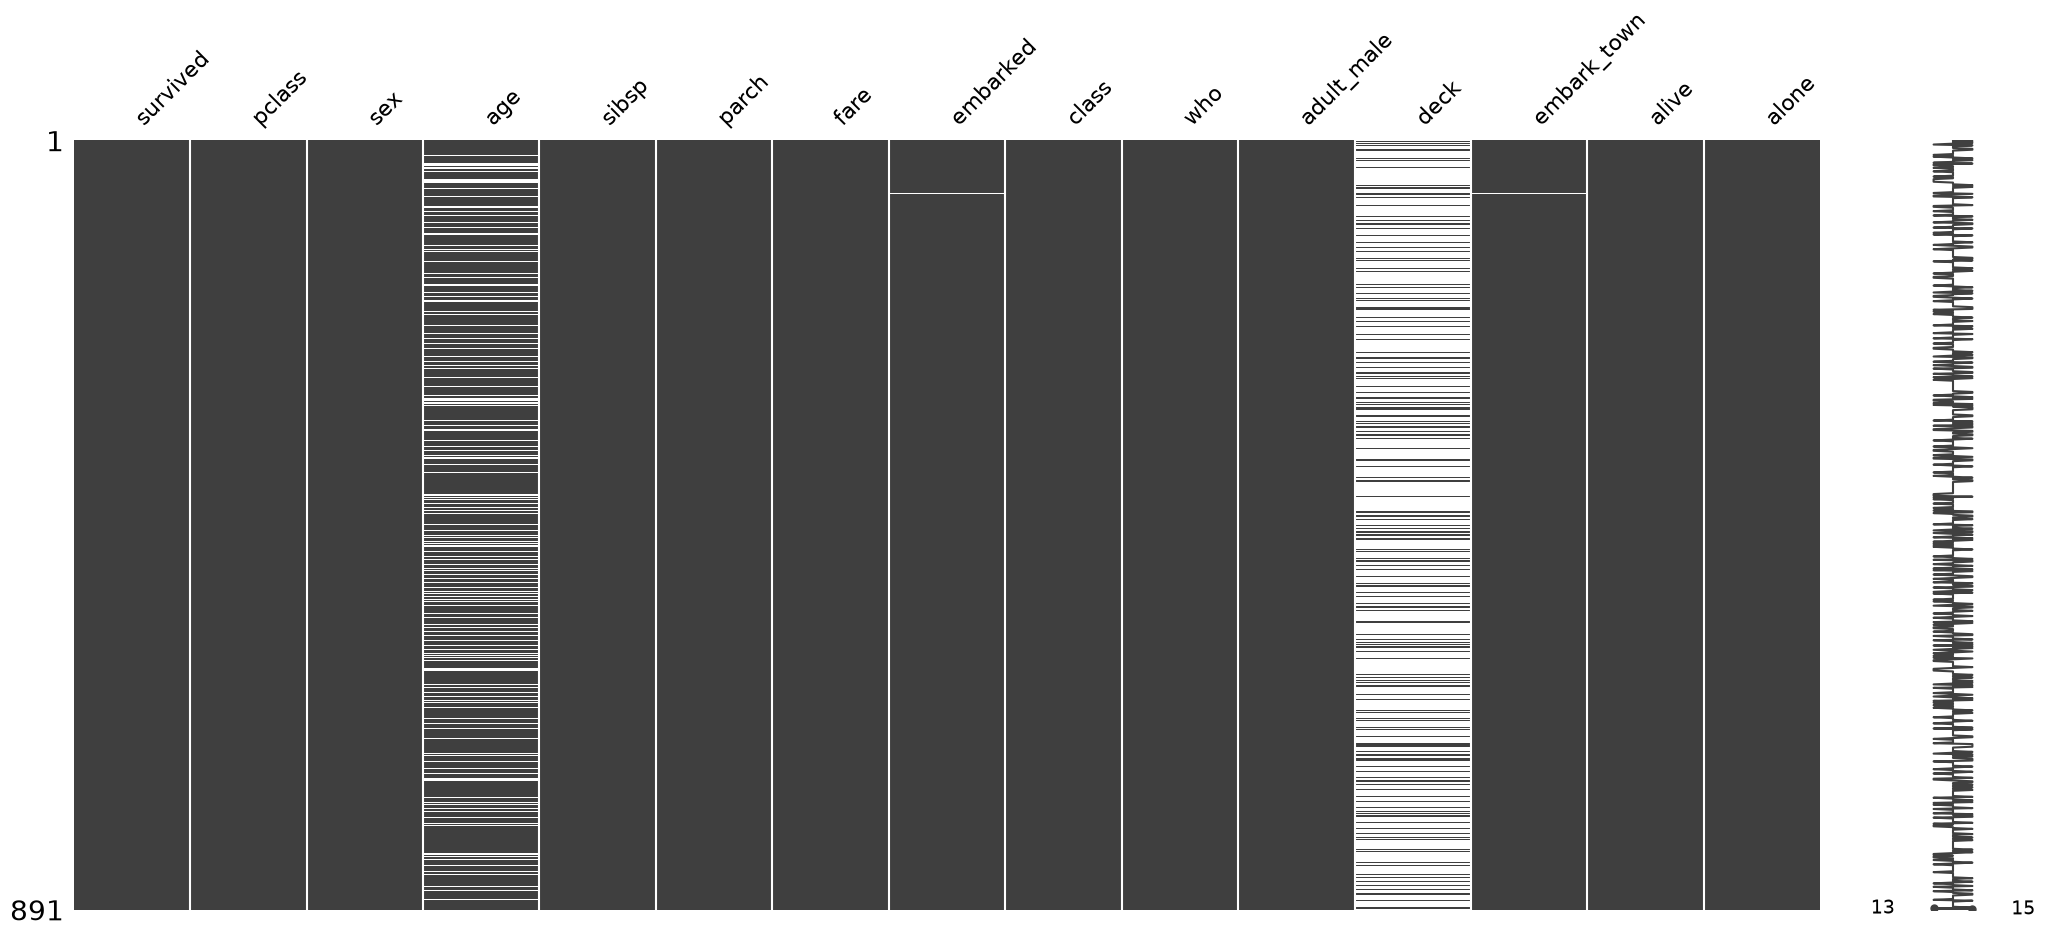

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    str     
 12  alive        891 non-null    str     
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(5)
memory usage: 99.0 KB
None
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked     

In [17]:
#Задание 1. Titanic — пропуски

import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("titanic")
print(df.info())
print(df.isna().sum())

msno.matrix(df)
plt.show()

df["age"] = df["age"].fillna(df["age"].mean())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df = df.drop(columns=["deck"])

print(df.info())
print(df.isna().sum())

До: 344


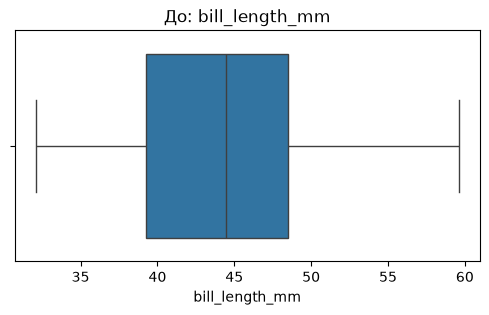

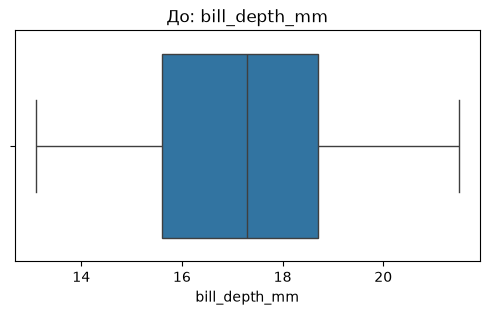

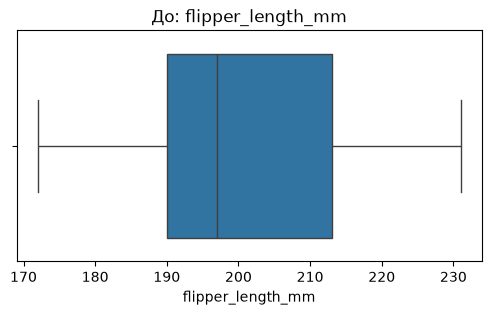

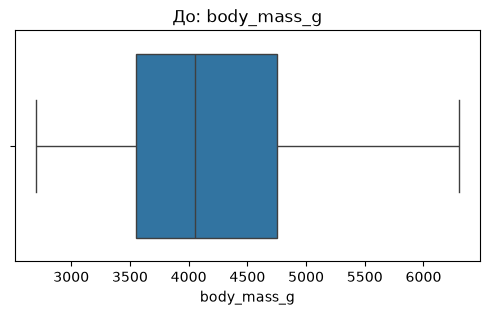

После: 342


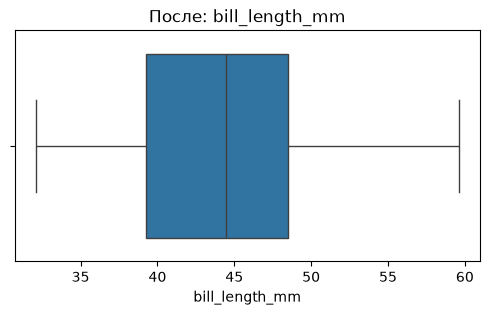

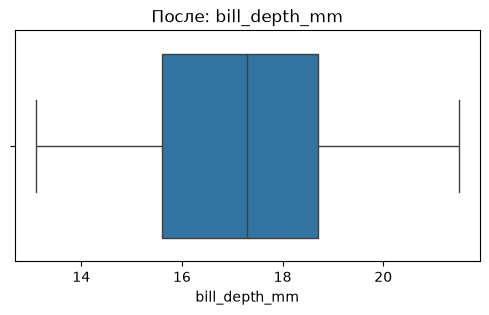

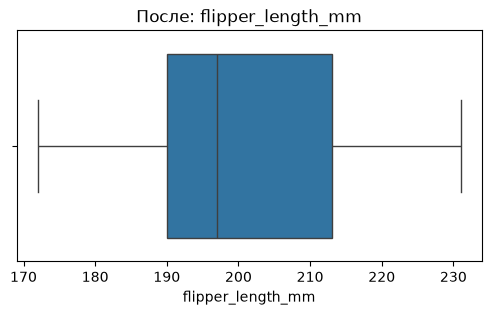

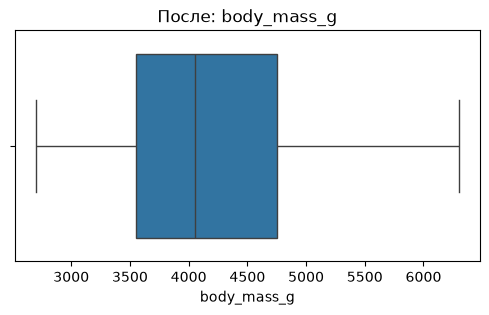

In [18]:
#Задание 2. Penguins — выбросы
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("penguins")
print("До:", len(df))

cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

for col in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"До: {col}")
    plt.show()

def remove_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[col] >= lower) & (data[col] <= upper)]

for col in cols:
    df = remove_outliers(df, col)

print("После:", len(df))

for col in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"После: {col}")
    plt.show()

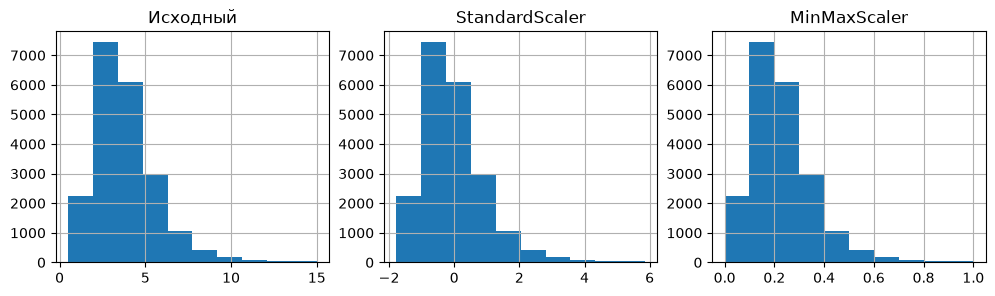

In [5]:
#Задание 3. California Housing — масштабирование
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler

data = fetch_california_housing(as_frame=True)
df = data.frame

scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

df_std = df.copy()
df_std[["MedInc"]] = scaler_std.fit_transform(df[["MedInc"]])

df_minmax = df.copy()
df_minmax[["MedInc"]] = scaler_minmax.fit_transform(df[["MedInc"]])

plt.figure(figsize=(12,3))
plt.subplot(1,3,1)
df["MedInc"].hist()
plt.title("Исходный")

plt.subplot(1,3,2)
df_std["MedInc"].hist()
plt.title("StandardScaler")

plt.subplot(1,3,3)
df_minmax["MedInc"].hist()
plt.title("MinMaxScaler")
plt.show()

In [7]:
#Задание 4. Adult — кодирование
import pandas as pd
from sklearn.preprocessing import LabelEncoder

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
cols = ["age","workclass","fnlwgt","education","education-num","marital-status",
        "occupation","relationship","race","sex","capital-gain","capital-loss",
        "hours-per-week","native-country","income"]
df = pd.read_csv(url, header=None, names=cols)
df = df[["education", "marital-status", "occupation", "income"]]
print("До:", df.shape)

education_order = {
    " Preschool":0," 1st-4th":1," 5th-6th":2," 7th-8th":3," 9th":4,
    " 10th":5," 11th":6," 12th":7," HS-grad":8," Some-college":9,
    " Assoc-voc":10," Assoc-acdm":11," Bachelors":12," Masters":13,
    " Prof-school":14," Doctorate":15
}
df["education_encoded"] = df["education"].map(education_order)
df = pd.get_dummies(df, columns=["marital-status", "occupation"], drop_first=True)
print("После:", df.shape)
print(df.head())

До: (32561, 4)
После: (32561, 23)
    education  income  education_encoded  marital-status_ Married-AF-spouse  \
0   Bachelors   <=50K                 12                              False   
1   Bachelors   <=50K                 12                              False   
2     HS-grad   <=50K                  8                              False   
3        11th   <=50K                  6                              False   
4   Bachelors   <=50K                 12                              False   

   marital-status_ Married-civ-spouse  marital-status_ Married-spouse-absent  \
0                               False                                  False   
1                                True                                  False   
2                               False                                  False   
3                                True                                  False   
4                                True                                  False   

   marital

In [16]:
#Задание 5. Heart Disease — комплексный EDA

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print(df.info())
print(df.isna().sum())

cols = ["mean radius", "mean texture", "mean perimeter", "mean area"]
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

num_cols = ["mean radius", "mean texture", "mean perimeter", "mean area"]
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df["target"] = LabelEncoder().fit_transform(df["target"])

print("Готово:", df.shape)
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null